Vamos a crear una red neuronal para tratar con un conjunto mucho más grandes, el dataset MNIST de dígitos. Veremos que el tiempo de cómputo se incrementa y que se hace necesario el uso de GPU, el cual hace keras por nosotros

# Conjunto MNIST de dígitos

Son 70.000 imágenes de dígitos manuscritos del 0 al 9. El tamaño es 28X28 píxeles y están en escala de grises. El conjunto se divide en 60.000 imágenes para train y 10.000 para test. Vamos a crear una red neuronal capaz de "ver", pero por ahora, sin usar opeadores avanzados, es decir, convolución (CNN - Convolution Neural Network).

In [1]:
import keras
from keras.datasets import mnist
from matplotlib import pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# El método shape no devuelve la forma del conjunto. 60.000 imágenes de 28x28
print("Shape: ", x_train.shape)

Shape:  (60000, 28, 28)


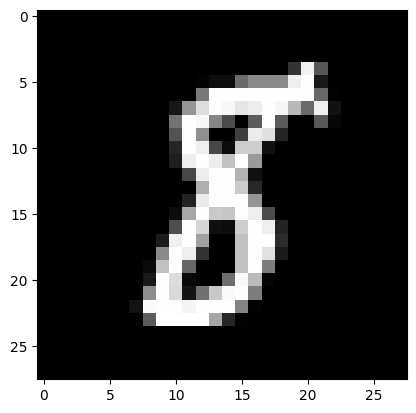

In [4]:
# Visualizar una image, por ejemplo la que tiene índice 125

image= np.array(x_train[125], dtype='float')
plt.imshow(image, cmap='gray')
plt.show()

In [5]:
print("Label: ", y_train[125])

Label:  8


También es necesario o muy recomendable comprobar en qué rango de valores se mueven las muestras de la imagen.

In [6]:
print("Max value: ", max(x_train[125].reshape(784)))
print("Min value: ", min(x_train[125].reshape(784)))

Max value:  255
Min value:  0


In [7]:
print("Elemento 125: ", x_train[125])
print("Elemento 125: ", x_train[125].reshape(784))

Elemento 125:  [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0  52 241  86   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  13  13 108 137 137
  137 238 254  24   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 121 254 254 254 254 254
  254 254 254 103   2   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  23 149 222 254 248 229 237 254
  246 184 105 241  18   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 115 254

Vemos que cada píxel es un byte con rango 0 a 255 en formato entero. Esta escala no es adecuada para una ANN, así que habría que normalizar. Normalmente era más adecuado para que la red aprenda bien centrar en -0.5 a 0.5. No es obligatorio, porque con las nuevas capas BatchNormalization, Dropout, etc.
funciona también muy bien normalizar entre 0 y 1.

In [8]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255 # Escalar a un rango entre 0 y 1
x_test /= 255

x_train -= 0.5 # Desplazar el rango a -0.5 y 0.5
x_test -= 0.5

In [9]:
print("Max value: ", max(x_train[125].reshape(784)))
print("Min value: ", min(x_train[125].reshape(784)))

Max value:  0.5
Min value:  -0.5


In [10]:
# Redimensionar todas las imágenes
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [11]:
print("Elemento 125: ", x_train[125])
print("Elemento 125: ", x_train[125].reshape(784))

Elemento 125:  [-0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        -0.5
 -0.5        -0.5        -0.5        -0.5        -0.5        

In [12]:
# Preparar las etiquetas transformándolas a fomato one_hot.
y_train = keras.utils.to_categorical(y_train, 10) # 10 clases
y_test = keras.utils.to_categorical(y_test, 10)

In [13]:
print("Label: ", y_train[125])

Label:  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


# Preparación del modelo

Problema de clasificación con 10 clases posibles. La capa de salida debe tener 10 neuronas. La capa de entrada debe tener 784 neuronas que son 28x28 píxeles. En la capa oculta no hay forma de saber a priori, ni el número óptimo de capas ni de neuronas. Vamos a probar con una sola oculta de 20 neuronas. Como función de activación vamos a usar sigoide en la capa oculta. En la capa de salida vamos a usar softmax(clasificación). Se podría crear con el modelo Sequential, pero vamos a hacelo con el no secuencial, que es una API funcional de Keras.

In [14]:
from keras.src.utils.audio_dataset_utils import prepare_dataset
from keras.layers import Input, Dense
from keras.models import Model

inputs = Input(shape=(784,)) # Capa de entrada
# Crea una capa oculta de 20 neuronas conectadas con las de la capa de entrada
output_h = Dense(units=20, activation='sigmoid')(inputs)
# Capa de salida
predictions = Dense(units=10, activation='softmax')(output_h)

model = Model(inputs=inputs, outputs=predictions)

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento

In [16]:
model.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=1.0), metrics=['accuracy'])

In [17]:
history = model.fit(x_train, y_train, epochs=50, batch_size=30, validation_data=(x_test,y_test))

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5524 - loss: 0.0650 - val_accuracy: 0.8883 - val_loss: 0.0210
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8865 - loss: 0.0198 - val_accuracy: 0.9114 - val_loss: 0.0154
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.0156 - val_accuracy: 0.9171 - val_loss: 0.0136
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9145 - loss: 0.0137 - val_accuracy: 0.9229 - val_loss: 0.0124
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9219 - loss: 0.0125 - val_accuracy: 0.9271 - val_loss: 0.0118
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9246 - loss: 0.0119 - val_accuracy: 0.9297 - val_loss: 0.0113
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9286 - loss: 0.0113 - val_accuracy: 0.9314 - val_loss: 0.0108
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9297 - loss: 0.0110 - 

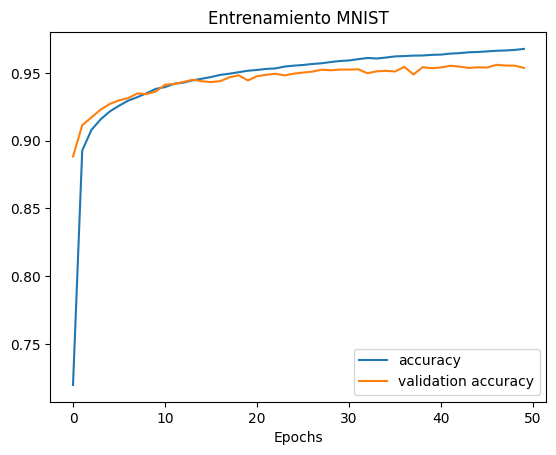

In [18]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title('Entrenamiento MNIST')
plt.xlabel('Epochs')
plt.legend(loc="lower right")

# Producción

In [19]:
import numpy as np

In [20]:
predictions = np.round(model.predict(x_test), 2)
print(f"Desired output: {y_test[1]}")
print(f"Predicted output: {predictions[1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Desired output: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Predicted output: [0.   0.   0.91 0.01 0.   0.08 0.   0.   0.   0.  ]


In [21]:
for i in range(100):
  if np.argmax(predictions[i]) == np.argmax(y_test[i]):
    print(predictions[i], "->", y_test[i])
  else:
    print(predictions[i], "->", y_test[i], "X")

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] -> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0.   0.   0.91 0.01 0.   0.08 0.   0.   0.   0.  ] -> [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0.   0.95 0.01 0.   0.   0.   0.01 0.   0.03 0.  ] -> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.] -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.01] -> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0.   0.96 0.01 0.   0.   0.   0.   0.01 0.01 0.  ] -> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.   0.   0.   0.   0.97 0.01 0.   0.   0.01 0.01] -> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0.02 0.   0.   0.   0.   0.13 0.86 0.   0.   0.  ] -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] X
[0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.99] -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0.99 0.   0.   0.   0.   0.   0.   0.   0.   0.  ] -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.   0.   0.   0.   0.   0.02 0.96 0.   0.01 0.  ] -> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[0.   0.   0. 

# Conjuntos de entrenamiento, validación y test

Si nos enfrentáramos a un problema de clasificación con responsabilildad deberíamos ser capaces de asegurar que el rendimiento que decimos que tiene nuestra red es el que realmente tiene (y no necesariamente una red, sino a cualquier modelo de clasificación que utilicemos. No solo de redes vive el experto en machine learning).

Para ello, en este ejemplo hemos hecho uso del conjunto de test. Pero, cuando entrenamos una red hacemos muchas pruebas, muchos cambios en su configuración (los hiperparámetros) buscando una de ellas que nos dé los mejores resultados. Llegará un momento en el que hemos hecho tantas modificaciones en la red que nuestro conjunto de test logrará un buen accuracy. Sin embargo, ¿cómo podemos estar seguros de que la red funcionaría bien para un nuevo conjunto de test? Es decir, quizá hayamos involuntariamente optimizado la red para que funcione bien sobre el conjunto de test.

La forma de asegurar que hemos entrenado una red que generaliza correctamente es la que hemos usado siempre en clase, disponer de tres conjuntos: entrenamiento, validación y test. Con el de entrenamiento, entrenamos, y utilizaremos el conjunto de validación para comprobar el nivel de accuracy logrado en ese modelo. Al final de todas las pruebas que hayamos hecho, dispondremos de nuestro modelo final. En ese momento tomaremos nuestro conjunto de test (que previamente habíamos guardado bajo llave para evitar la tentación de utilizarlo antes) y lo pasaremos por la red. El accuracy que nos devuelva este conjunto de test será nuestro resultado final.